In [1]:
import os
%pwd

'e:\\Research\\Detecting-Thyroid-Cancer\\research'

In [2]:
os.chdir("../")
%pwd

'e:\\Research\\Detecting-Thyroid-Cancer'

In [3]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class ExplainabilityConfig:
    root_dir: Path
    heatmap_dir: Path
    model_path: Path
    data_dir: Path
    params_image_size: list
    params_classes: int

In [4]:
from ThyroidCancer.constants import *
from ThyroidCancer.utils.common import read_yaml, create_directories

In [5]:
class ConfigurationManager:
    def __init__(
        self, 
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_explainability_config(self) -> ExplainabilityConfig:
        config = self.config.explainability
        fl_config = self.config.federated_training
        data_ingestion_config = self.config.data_ingestion
        
        create_directories([config.root_dir, config.heatmap_dir])

        explainability_config = ExplainabilityConfig(
            root_dir=Path(config.root_dir),
            heatmap_dir=Path(config.heatmap_dir),
            model_path=Path(fl_config.aggregated_model_path),
            data_dir=Path(data_ingestion_config.unzip_dir),
            params_image_size=self.params.IMAGE_SIZE,
            params_classes=self.params.CLASSES
        )

        return explainability_config

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from ThyroidCancer import logger
import cv2
import glob
import random

In [7]:
class Explainability:
    def __init__(self, config: ExplainabilityConfig):
        self.config = config
        
    def _build_model(self):
        """Rebuild the model architecture"""
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=self.config.params_image_size,
            weights=None, # Load from file later
            include_top=False
        )
        
        x = tf.keras.layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.5, name="top_dropout")(x)
        predictions = tf.keras.layers.Dense(
            units=self.config.params_classes,
            activation="softmax",
            name="predictions"
        )(x)

        model = tf.keras.models.Model(
            inputs=base_model.input,
            outputs=predictions,
            name="EfficientNetB0_Explainability"
        )
        return model

    def load_model(self):
        logger.info(f"Loading model from {self.config.model_path}...")
        self.model = self._build_model()
        self.model.load_weights(self.config.model_path)
        logger.info("Model loaded successfully.")
        
    def make_gradcam_heatmap(self, img_array, last_conv_layer_name="top_activation", pred_index=None):
        # First, we create a model that maps the input image to the activations
        # of the last conv layer as well as the output predictions
        
        # EfficientNetB0 last conv layer name is typically 'top_activation'
        # Let's find the last Conv2D layer if name is not provided or incorrect
        if last_conv_layer_name is None:
            for layer in reversed(self.model.layers):
                if isinstance(layer, tf.keras.layers.Conv2D):
                    last_conv_layer_name = layer.name
                    break
        
        grad_model = tf.keras.models.Model(
            [self.model.inputs], [self.model.get_layer(last_conv_layer_name).output, self.model.output]
        )

        # Then, we compute the gradient of the top predicted class for our input image
        # with respect to the activations of the last conv layer
        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        # This is the gradient of the output neuron (top predicted or chosen)
        # with regard to the output feature map of the last conv layer
        grads = tape.gradient(class_channel, last_conv_layer_output)

        # This is a vector where each entry is the mean intensity of the gradient
        # over a specific feature map channel
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # We multiply each channel in the feature map array
        # by "how important this channel is" with regard to the top predicted class
        # then sum all the channels to obtain the heatmap class activation
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        # For visualization purpose, we will also normalize the heatmap between 0 & 1
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        return heatmap.numpy()
    
    def save_and_display_gradcam(self, img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
        # Load the original image
        img = cv2.imread(img_path)
        img = cv2.resize(img, (self.config.params_image_size[0], self.config.params_image_size[1]))
        
        # Rescale heatmap to a range 0-255
        heatmap = np.uint8(255 * heatmap)

        # Use jet colormap to colorize heatmap
        jet = cm.get_cmap("jet")

        # Use RGB values of the colormap
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[heatmap]

        # Create an image with RGB colorized heatmap
        jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
        jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
        jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

        # Superimpose the heatmap on original image
        superimposed_img = jet_heatmap * alpha + img
        superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

        # Save the superimposed image
        superimposed_img.save(cam_path)
        logger.info(f"Saved Grad-CAM image to {cam_path}")
        
        # Display
        plt.figure(figsize=(10, 10))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Image")
        
        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title("Grad-CAM")
        plt.show()

    def generate_explanations(self, num_samples=3):
        # Find some images
        # Using recursive glob to find images in subdirectories
        all_images = glob.glob(str(self.config.data_dir / "**" / "*.jpg"), recursive=True) + \
                     glob.glob(str(self.config.data_dir / "**" / "*.png"), recursive=True)
        
        if not all_images:
            logger.warning("No images found for explanation!")
            return
            
        selected_images = random.sample(all_images, min(len(all_images), num_samples))
        
        for i, img_path in enumerate(selected_images):
            logger.info(f"Processing image: {img_path}")
            
            # Preprocess image
            img = tf.keras.preprocessing.image.load_img(
                img_path, target_size=self.config.params_image_size[:-1]
            )
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0
            
            # Generate heatmap
            # Use EfficientNetB0's last activation layer for Grad-CAM
            heatmap = self.make_gradcam_heatmap(img_array, last_conv_layer_name='top_activation')
            
            save_path = self.config.heatmap_dir / f"gradcam_{i}.jpg"
            self.save_and_display_gradcam(img_path, heatmap, str(save_path))

[2025-11-20 22:01:19,887: INFO: common: yaml file: config\config.yaml loaded successfully]
[2025-11-20 22:01:19,887: INFO: common: yaml file: params.yaml loaded successfully]
[2025-11-20 22:01:19,892: INFO: common: created directory at: artifacts]
[2025-11-20 22:01:19,894: INFO: common: created directory at: artifacts/explainability]
[2025-11-20 22:01:19,896: INFO: common: created directory at: artifacts/explainability/heatmaps]
[2025-11-20 22:01:19,897: INFO: 4225225270: Loading model from artifacts\federated_training\aggregated_model.h5...]
[2025-11-20 22:01:25,187: INFO: 4225225270: Model loaded successfully.]
[2025-11-20 22:01:25,208: INFO: 4225225270: Processing image: artifacts\data_ingestion\Thyroid Data\0\1710.jpg]
[2025-11-20 22:01:26,532: INFO: 4225225270: Saved Grad-CAM image to artifacts\explainability\heatmaps\gradcam_0.jpg]


C:\Users\Sushmoy\AppData\Local\Temp\ipykernel_22252\4225225270.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


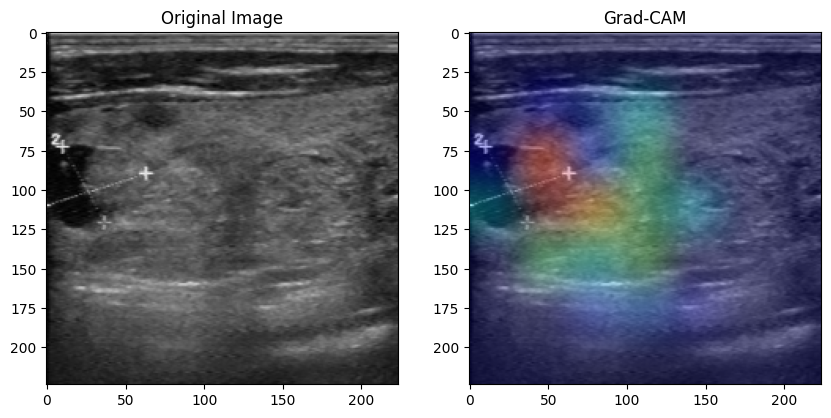

[2025-11-20 22:01:27,020: INFO: 4225225270: Processing image: artifacts\data_ingestion\Thyroid Data\1\2222.jpg]
[2025-11-20 22:01:28,187: INFO: 4225225270: Saved Grad-CAM image to artifacts\explainability\heatmaps\gradcam_1.jpg]


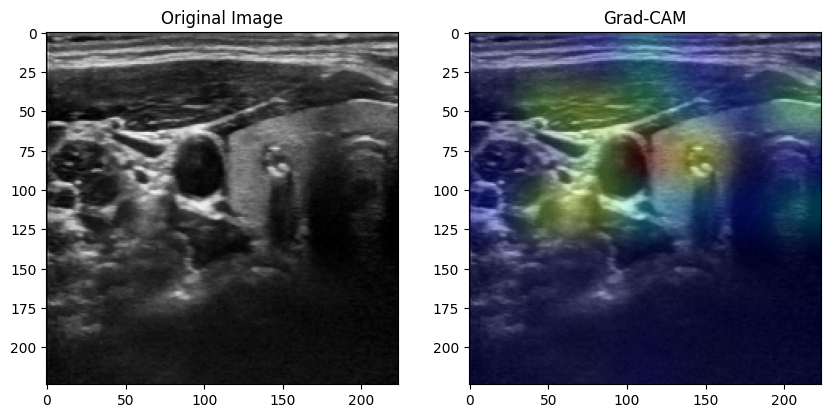

[2025-11-20 22:01:28,583: INFO: 4225225270: Processing image: artifacts\data_ingestion\Thyroid Data\0\1001.jpg]
[2025-11-20 22:01:29,656: INFO: 4225225270: Saved Grad-CAM image to artifacts\explainability\heatmaps\gradcam_2.jpg]


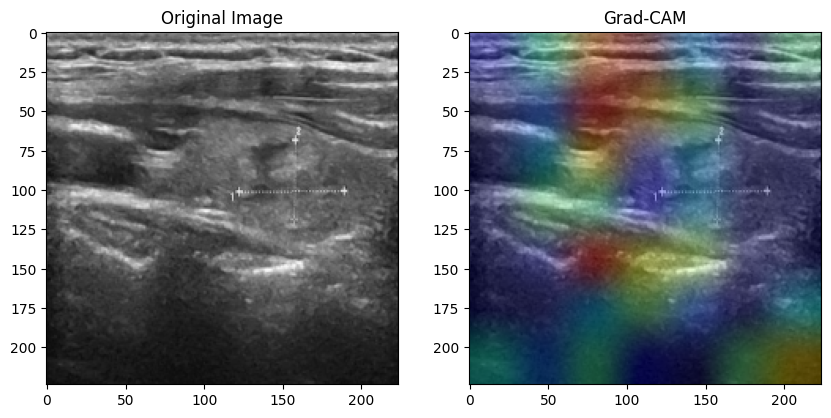

In [8]:
try:
    config = ConfigurationManager()
    exp_config = config.get_explainability_config()
    explainability = Explainability(config=exp_config)
    
    explainability.load_model()
    explainability.generate_explanations()
    
except Exception as e:
    raise e